In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rishidamarla/heart-disease-prediction/Heart_Disease_Prediction.csv


In [2]:
# Data Manipulation & Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Notebook Settings
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("Setup Complete: Libraries and visualization styles initialized.")

Setup Complete: Libraries and visualization styles initialized.


In [3]:
df=pd.read_csv("/kaggle/input/datasets/rishidamarla/heart-disease-prediction/Heart_Disease_Prediction.csv")
df

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence


In [4]:
df.columns = df.columns.str.strip()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,270.0,54.433333,9.109067,29.0,48.0,55.0,61.0,77.0
Sex,270.0,0.677778,0.468195,0.0,0.0,1.0,1.0,1.0
Chest pain type,270.0,3.174074,0.950090,1.0,3.0,3.0,4.0,4.0
BP,270.0,131.344444,17.861608,94.0,120.0,130.0,140.0,200.0
Cholesterol,270.0,249.659259,51.686237,126.0,213.0,245.0,280.0,564.0
FBS over 120,270.0,0.148148,0.355906,0.0,0.0,0.0,0.0,1.0
EKG results,270.0,1.022222,0.997891,0.0,0.0,2.0,2.0,2.0
Max HR,270.0,149.677778,23.165717,71.0,133.0,153.5,166.0,202.0
Exercise angina,270.0,0.329630,0.470952,0.0,0.0,0.0,1.0,1.0
ST depression,270.0,1.050000,1.145210,0.0,0.0,0.8,1.6,6.2


In [7]:
df.isna().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Heart Disease"].value_counts()

Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64

In [10]:
df["Heart Disease"].value_counts(normalize=True) * 100

Heart Disease
Absence     55.555556
Presence    44.444444
Name: proportion, dtype: float64

In [11]:
df.columns.tolist()

['Age',
 'Sex',
 'Chest pain type',
 'BP',
 'Cholesterol',
 'FBS over 120',
 'EKG results',
 'Max HR',
 'Exercise angina',
 'ST depression',
 'Slope of ST',
 'Number of vessels fluro',
 'Thallium',
 'Heart Disease']

In [12]:
df["Heart Disease"].unique()

array(['Presence', 'Absence'], dtype=object)

In [13]:
df["Heart Disease"] = df["Heart Disease"].map({
    "Absence": 0,
    "Presence": 1
})

In [14]:
df.corr(numeric_only=True)["Heart Disease"].sort_values(ascending=False)

Heart Disease              1.000000
Thallium                   0.525020
Number of vessels fluro    0.455336
Exercise angina            0.419303
ST depression              0.417967
Chest pain type            0.417436
Slope of ST                0.337616
Sex                        0.297721
Age                        0.212322
EKG results                0.182091
BP                         0.155383
Cholesterol                0.118021
FBS over 120              -0.016319
Max HR                    -0.418514
Name: Heart Disease, dtype: float64

In [15]:
df["Heart Disease"].value_counts(dropna=False)

Heart Disease
0    150
1    120
Name: count, dtype: int64

In [16]:
df.rename(columns={"Sex":"Gender"},inplace=True)


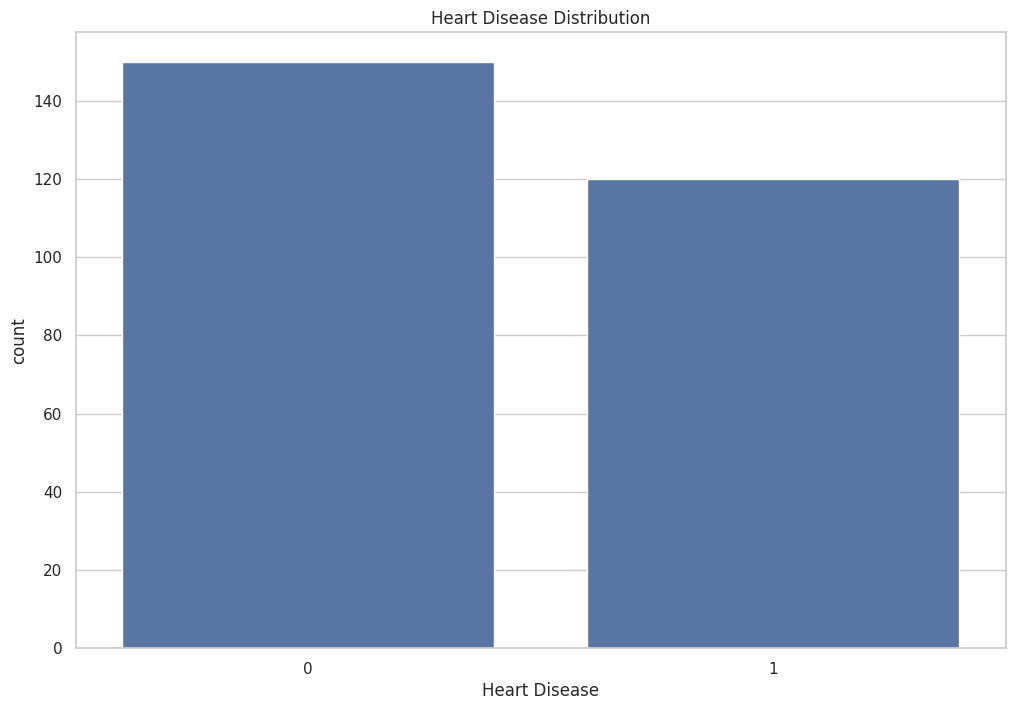

In [17]:
sns.countplot(data=df, x="Heart Disease")
plt.title("Heart Disease Distribution")
plt.show()

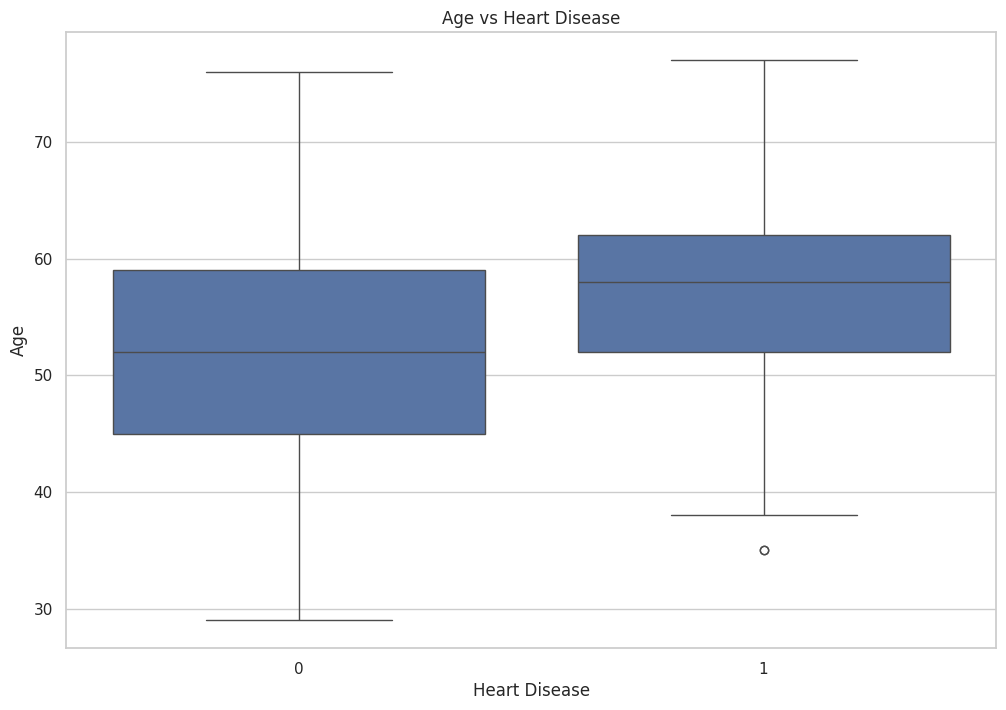

In [18]:
sns.boxplot(data=df, x="Heart Disease", y="Age")
plt.title("Age vs Heart Disease")
plt.show()

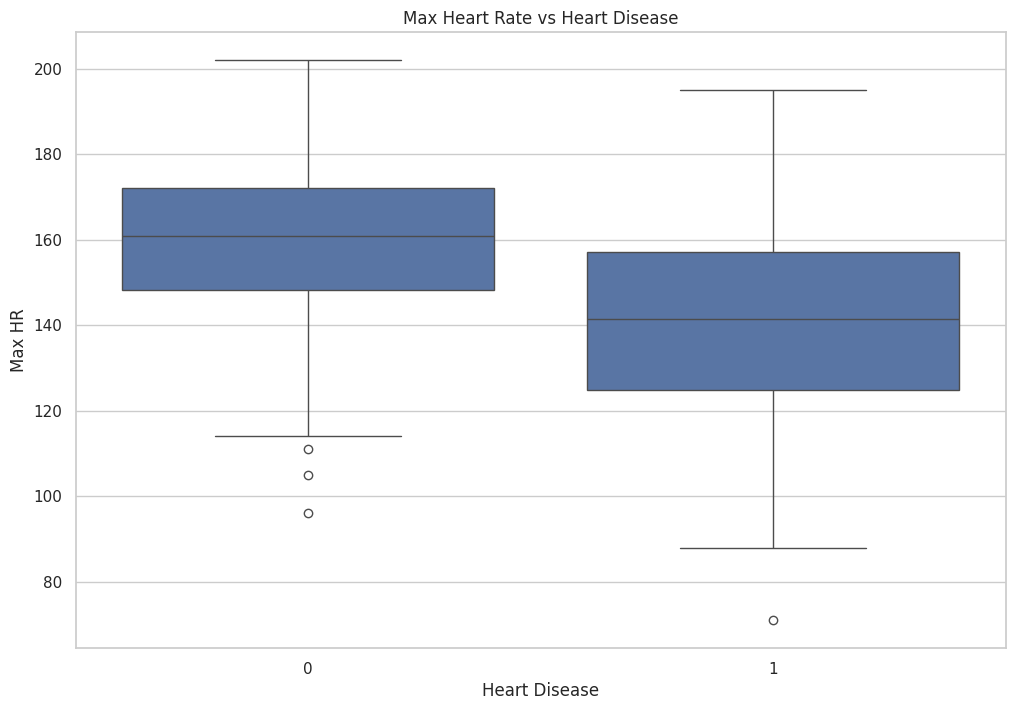

In [19]:
sns.boxplot(data=df, x="Heart Disease", y="Max HR")
plt.title("Max Heart Rate vs Heart Disease")
plt.show()

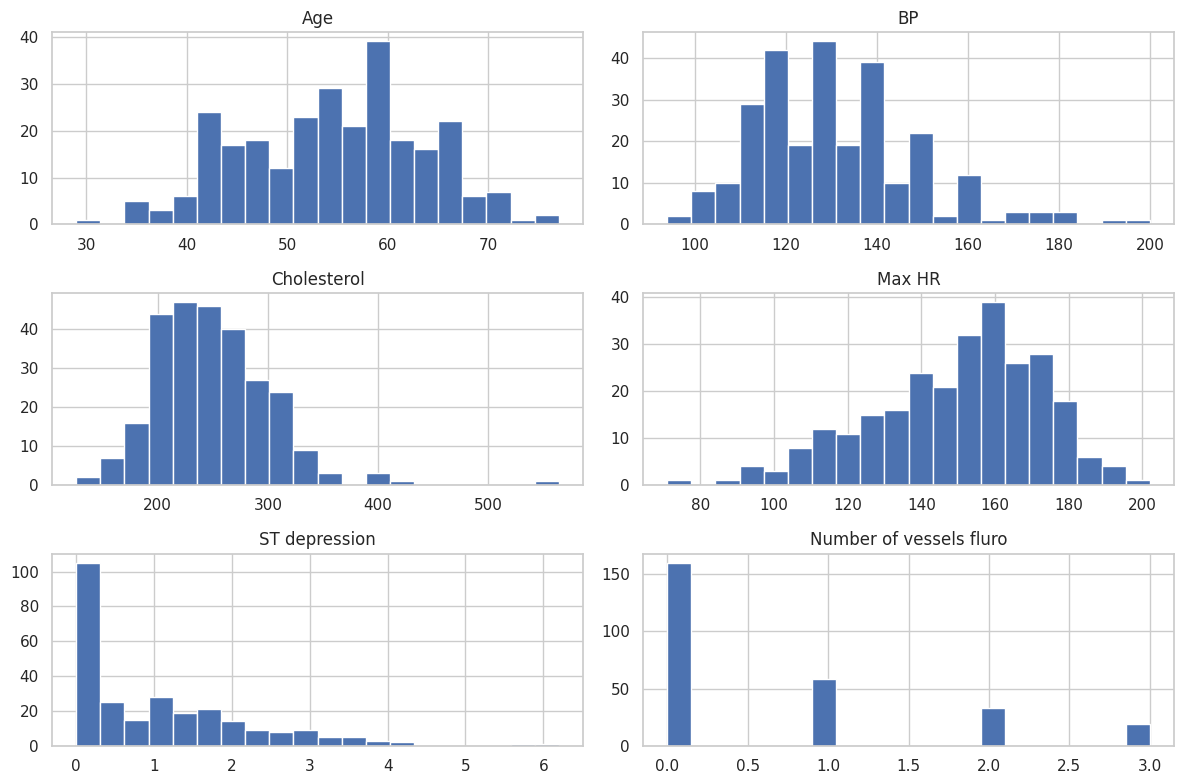

In [20]:
cols = ['Age', 'BP', 'Cholesterol', 'Max HR',
        'ST depression', 'Number of vessels fluro']

df[cols].hist(figsize=(12, 8), bins=20)

plt.tight_layout()
plt.show()

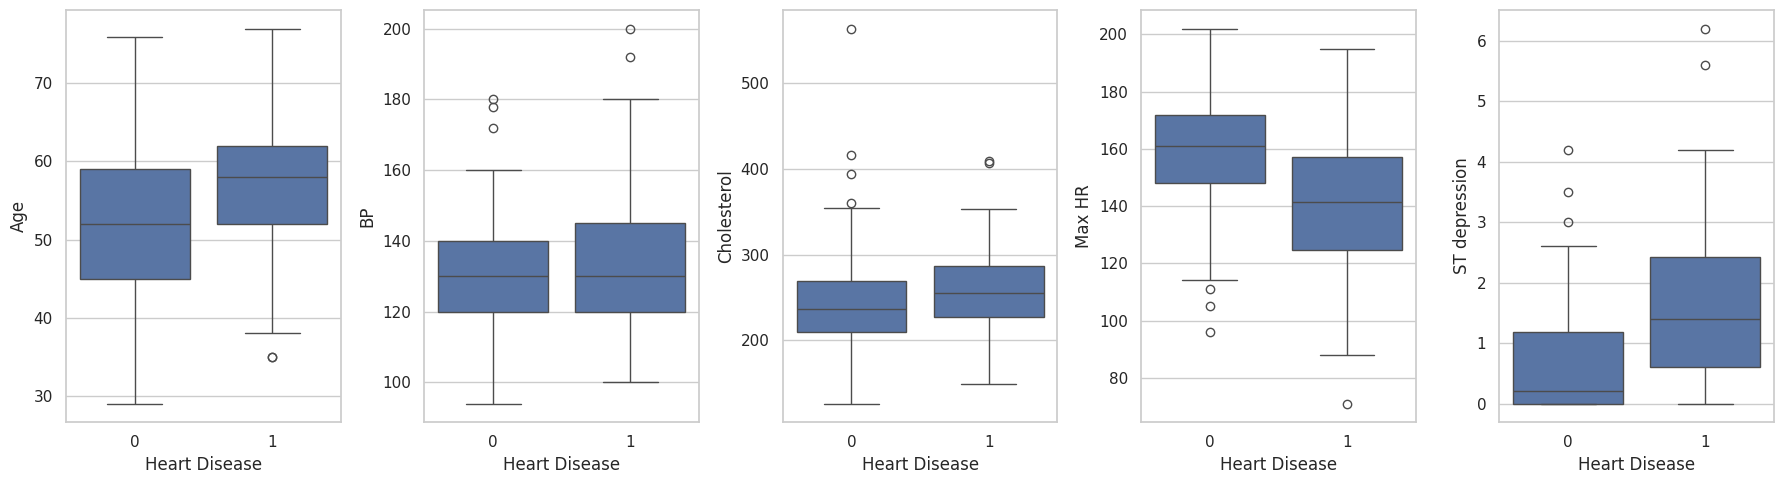

In [21]:
cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

fig, ax = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(cols):
    sns.boxplot(data=df, x='Heart Disease', y=col, ax=ax[i])

plt.tight_layout()
plt.show()

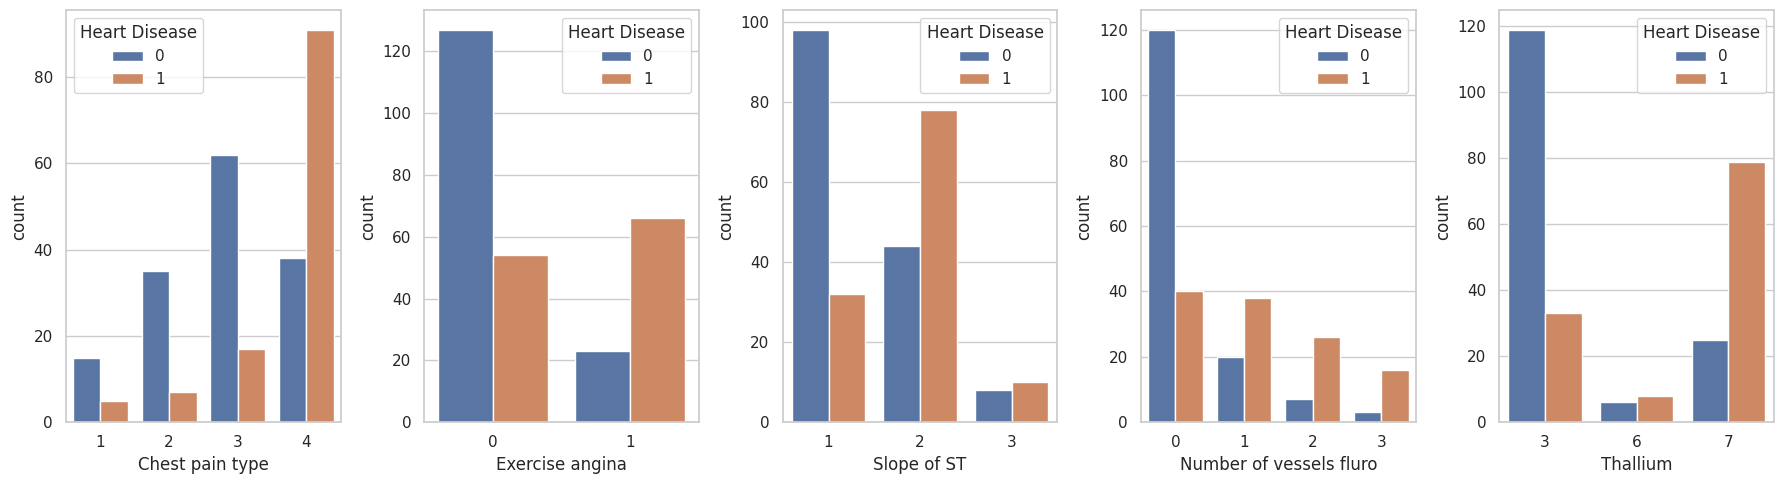

In [22]:
cols = ['Chest pain type', 'Exercise angina', 'Slope of ST',
        'Number of vessels fluro', 'Thallium']

fig, ax = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, hue='Heart Disease', ax=ax[i])

plt.tight_layout()
plt.show()

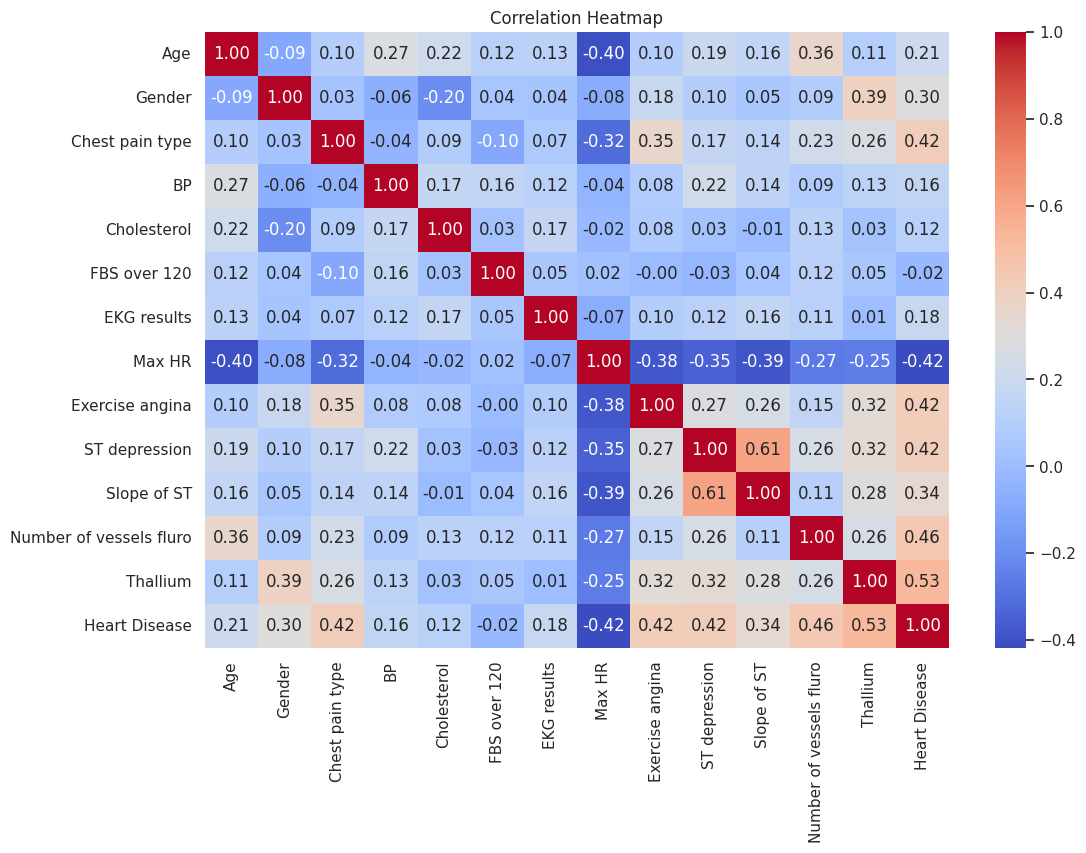

In [23]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [24]:
X = df.drop("Heart Disease", axis=1)
y = df["Heart Disease"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
X.dtypes

Age                          int64
Gender                       int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
dtype: object

In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [29]:
y_pred = model.predict(X_test_scaled)

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8518518518518519

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        30
           1       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54



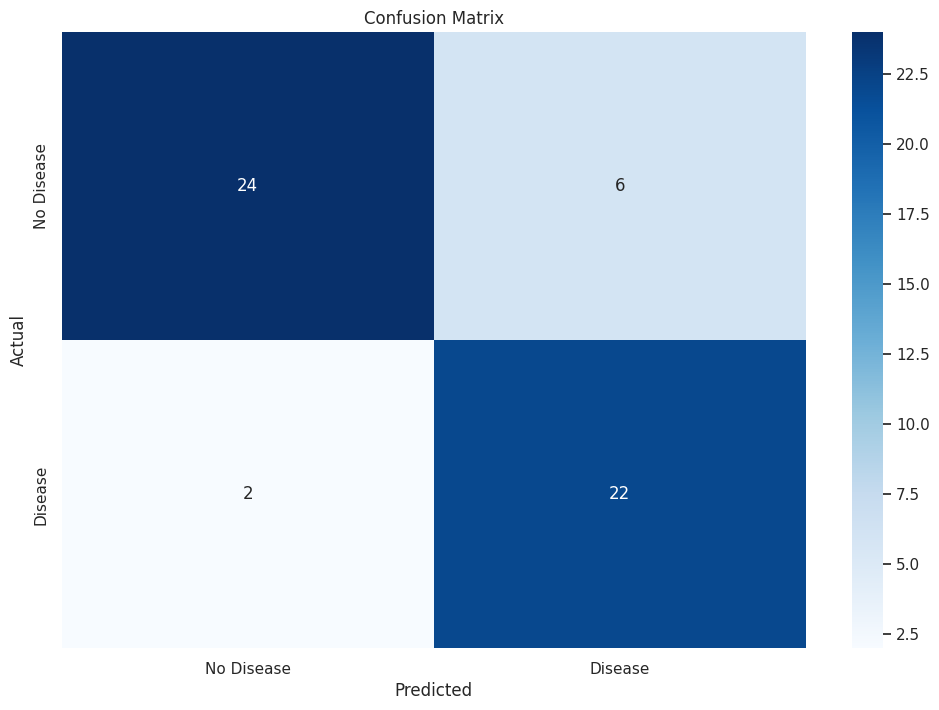

In [31]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

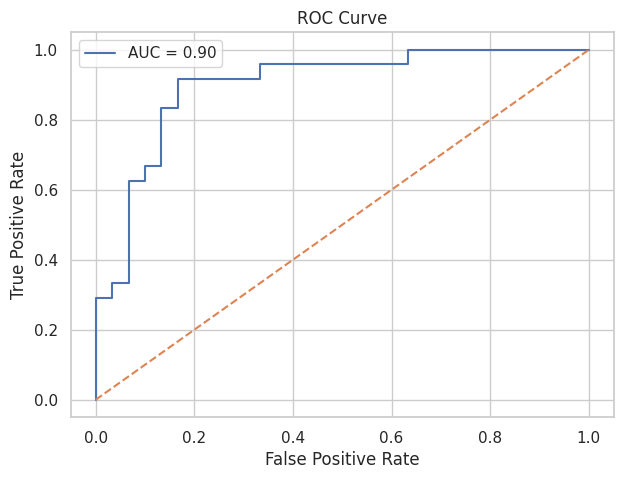

ROC-AUC: 0.898611111111111


In [32]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC:", auc)

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [34]:
rf_pred = rf_model.predict(X_test)

In [35]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8333333333333334

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.85        30
           1       0.80      0.83      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54



In [36]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.8666666666666667


In [37]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    "Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
11,Number of vessels fluro,1.185769
1,Gender,0.892690
2,Chest pain type,0.716115
12,Thallium,0.584150
8,Exercise angina,0.481365
10,Slope of ST,0.413009
3,BP,0.408808
4,Cholesterol,0.341274
9,ST depression,0.240702
6,EKG results,0.073109


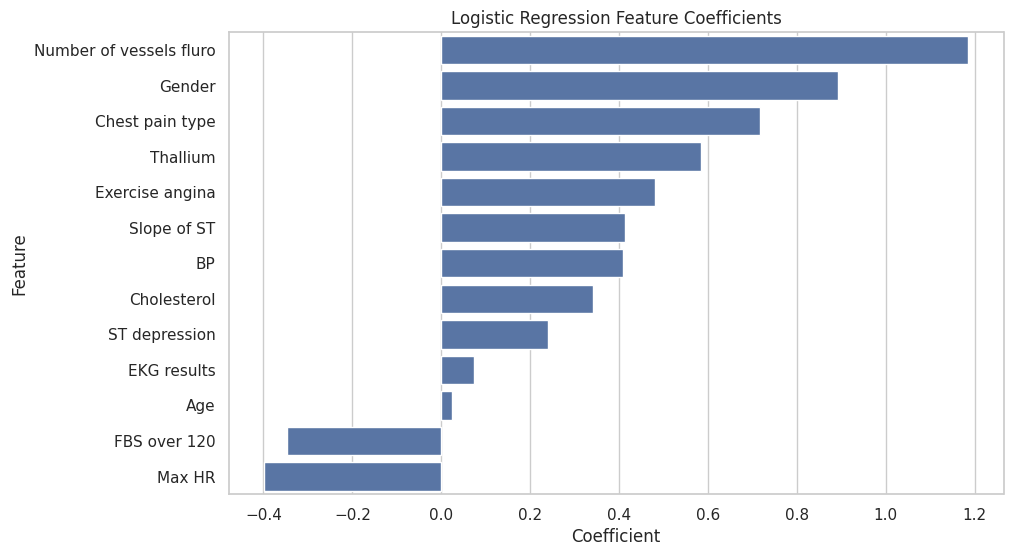

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Logistic Regression Feature Coefficients")
plt.show()

## Model Comparison

The two classification models were evaluated using Accuracy and ROC-AUC.

In [39]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [0.8519, 0.8333],
    'ROC-AUC': [0.9014, 0.8854]
})

comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.8519,0.9014
1,Random Forest,0.8333,0.8854


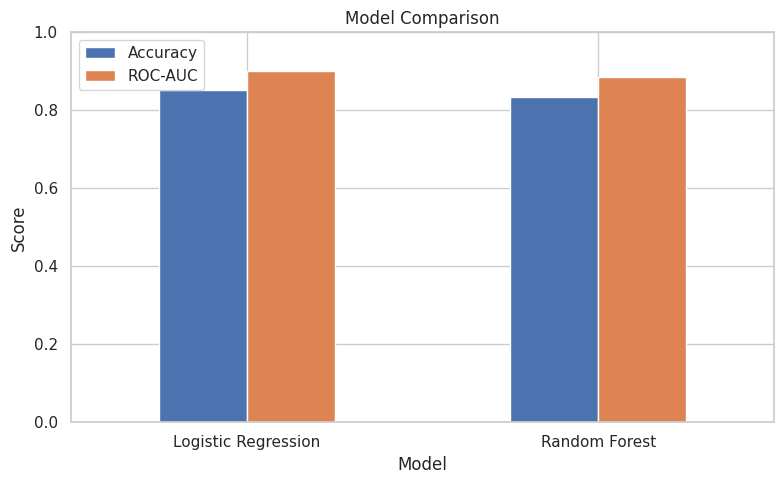

In [40]:
comparison.set_index('Model')[['Accuracy', 'ROC-AUC']].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Final Insights

- Logistic Regression achieved the best overall performance with an accuracy of 85.19%.
- Logistic Regression also achieved the highest ROC-AUC score of 0.90.
- Random Forest achieved an accuracy of 83.33% and a ROC-AUC of 0.89.
- The results show that Logistic Regression performed slightly better on this dataset.
- Number of vessels fluro, Gender, Chest pain type, and Thallium had relatively strong positive coefficients in the Logistic Regression model.
- Max HR and FBS over 120 had negative coefficients.
- Overall, the models were able to distinguish between patients with and without heart disease reasonably well.